In [ ]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q opencv-python matplotlib
!pip install -q git+https://github.com/facebookresearch/segment-anything.git


  Preparing metadata (setup.py) ... done


In [ ]:
!mkdir -p models
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -O models/sam.pth


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

from segment_anything import sam_model_registry, SamPredictor


(720, 1280, 3) uint8


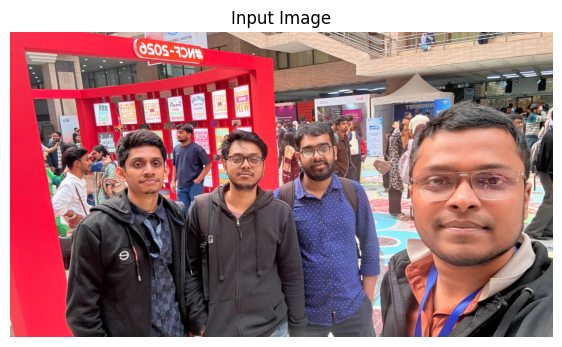

In [ ]:
image_path = "/content/drive/MyDrive/PersonRemovalProject/data/test_images/group.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(image.shape, image.dtype)

plt.figure(figsize=(7,7))
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_h"](checkpoint="models/sam.pth")
sam.to(device)

predictor = SamPredictor(sam)

predictor.set_image(image)

print("SAM loaded on:", device)


SAM loaded on: cuda


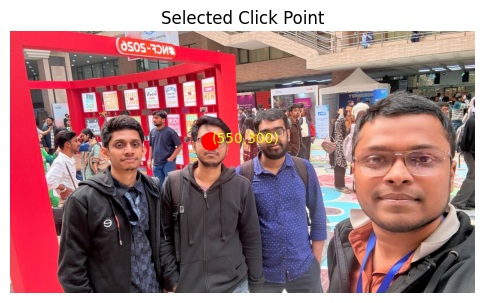

In [ ]:
click_x, click_y = 550, 300

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.scatter(click_x, click_y, c='red', s=150)
plt.text(click_x+5, click_y+5, f"({click_x},{click_y})", color='yellow')
plt.title("Selected Click Point")
plt.axis("off")
plt.show()


In [ ]:
input_point = np.array([[click_x, click_y]], dtype=np.float32)
input_label = np.array([1], dtype=np.int32)

masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]

print("Mask score:", scores.max())


Mask score: 0.96005285


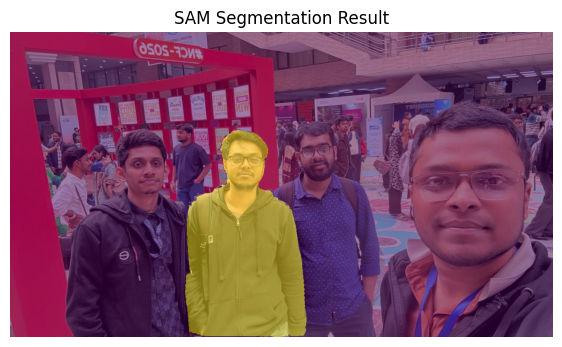

In [ ]:
plt.figure(figsize=(7,7))
plt.imshow(image)
plt.imshow(best_mask, alpha=0.5)
plt.title("SAM Segmentation Result")
plt.axis("off")
plt.show()


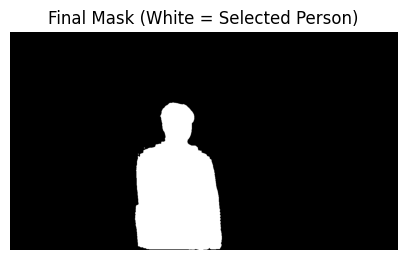

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(best_mask, cmap="gray")
plt.title("Final Mask (White = Selected Person)")
plt.axis("off")
plt.show()


In [ ]:
!pip install -q pytorch-lightning==1.5.10
!pip install -q omegaconf
!pip install -q scikit-image
!pip install -q tqdm


Requested pytorch-lightning==1.5.10 from https://files.pythonhosted.org/packages/18/f1/f59b307f75db1886c96e396eec878501510677394868680b8d2b8b58c47c/pytorch_lightning-1.5.10-py3-none-any.whl has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    torch (>=1.7.*)
           ~~~~~~^
Please use pip<24.1 if you need to use this version.
ERROR: Could not find a version that satisfies the requirement pytorch-lightning==1.5.10 (from versions: 0.0.2, 0.2, 0.2.2, 0.2.3, 0.2.4, 0.2.4.1, 0.2.5, 0.2.5.1, 0.2.5.2, 0.2.6, 0.3, 0.3.1, 0.3.2, 0.3.3, 0.3.4, 0.3.4.1, 0.3.5, 0.3.6, 0.3.6.1, 0.3.6.3, 0.3.6.4, 0.3.6.5, 0.3.6.6, 0.3.6.7, 0.3.6.8, 0.3.6.9, 0.4.0, 0.4.1, 0.4.2, 0.4.3, 0.4.4, 0.4.5, 0.4.6, 0.4.7, 0.4.8, 0.4.9, 0.5.0, 0.5.1, 0.5.1.2, 0.5.1.3, 0.5.2, 0.5.2.1, 0.5.3, 0.5.3.1, 0.5.3.2, 0.5.3.3, 0.6.0, 0.7.1, 0.7.3, 0.7.5, 0.7.6, 0.8.1, 0.8.3, 0.8.4, 0.8.5, 0.9.0, 0.10.0, 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4, 1.0.5, 1.0.6, 1.0.7, 1.0.8, 1.1.0, 1.1.1, 1.1.2, 1.1.3, 1.1.4, 1.1.5,

In [ ]:
!git clone https://github.com/saic-mdal/lama.git


Cloning into 'lama'...
remote: Enumerating objects: 478, done.
remote: Counting objects: 100% (320/320), done.
remote: Compressing objects: 100% (193/193), done.
remote: Total 478 (delta 173), reused 127 (delta 127), pack-reused 158 (from 1)
Receiving objects: 100% (478/478), 8.84 MiB | 16.33 MiB/s, done.
Resolving deltas: 100% (194/194), done.


In [ ]:
!mkdir -p lama/models
!wget -q https://huggingface.co/sam-hq/lama/resolve/main/big-lama.pt -O lama/models/big-lama.pt


In [ ]:
import os
import numpy as np
from skimage.io import imsave

os.makedirs("lama/input", exist_ok=True)
os.makedirs("lama/output", exist_ok=True)

imsave("lama/input/image.png", image)

lama_mask = (best_mask * 255).astype(np.uint8)
imsave("lama/input/image_mask.png", lama_mask)

print("Image & mask prepared correctly for LaMa")


Image & mask prepared correctly for LaMa


In [ ]:
!python lama/bin/predict.py \
  model.path=lama/models/big-lama.pt \
  indir=lama/input \
  outdir=lama/output



Traceback (most recent call last):
  File "/content/lama/bin/predict.py", line 14, in <module>
    from saicinpainting.evaluation.utils import move_to_device
ModuleNotFoundError: No module named 'saicinpainting'


In [ ]:
!ls lama/input

image_mask.png	image.png  mask.png


In [ ]:
!rm lama/input/mask.png


In [ ]:
!ls lama/input

image_mask.png	image.png


In [ ]:
!python lama/bin/predict.py \
  model.path=lama/models/big-lama.pt \
  indir=lama/input \
  outdir=lama/output


Traceback (most recent call last):
  File "/content/lama/bin/predict.py", line 14, in <module>
    from saicinpainting.evaluation.utils import move_to_device
ModuleNotFoundError: No module named 'saicinpainting'


In [ ]:
!ls lama/output


In [ ]:
!find lama/output -type f


In [ ]:
result = cv2.imread("")
result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,7))
plt.imshow(result)
plt.title("Final Result — Person Removed (LaMa)")
plt.axis("off")
plt.show()


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


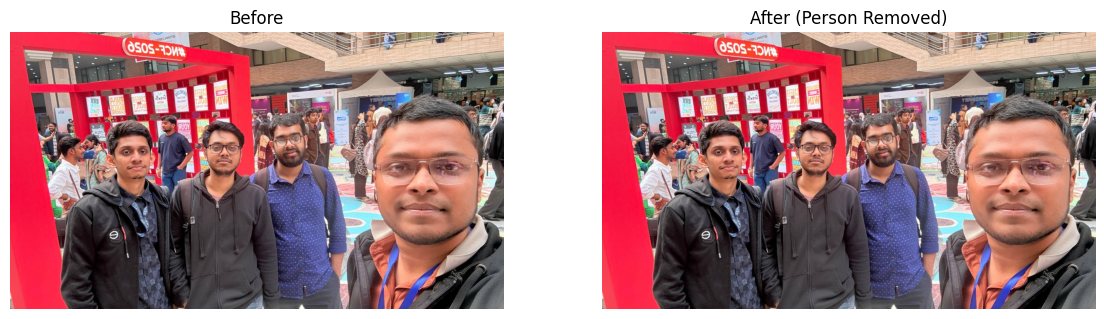

In [ ]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Before")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("After (Person Removed)")
plt.axis("off")

plt.show()
